# Bias, dispersion and MSE of the unfolded $\delta\Phi_j$ — paper figures (Figs. 12–14)

Parametric-bootstrap study of the point estimate for arXiv:2608.16107 v2.

**Procedure** (Appendix D of the paper): the expected counts $N_i$ predicted by the free best fit
(and the subtracted backgrounds) are fluctuated with independent Gaussians,
$n_i = N_i + \mathcal{N}(0,\sqrt{N_i})$, $B_i + \mathcal{N}(0,\sqrt{B_i})$;
each pseudo-dataset is refit with the identical procedure (same response matrix, $N_{\rm int}$,
non-negativity and monotonicity constraints), giving $\delta\Phi_j^{a}$, $a=1,\dots,N_{\rm boot}$. Then

$${b}_j=\langle\delta\Phi_j\rangle-\delta\hat\Phi_j,\qquad
\hat\sigma_j^2=\tfrac{1}{N_{\rm boot}-1}\sum_a\bigl[\delta\Phi_j^a-\langle\delta\Phi_j\rangle\bigr]^2,\qquad
{\rm MSE}_j={b}_j^2+\hat\sigma_j^2 .$$

**Data** — JSON files in `data/N{NINT}/`, produced with (≈ 70–85 min per configuration):
```
python scripts/run_bias_variance.py <1eV|5eV> <b|none> 3 10000 20260821 vertex_on <NINT> 1
```
$N_{\rm boot}=10^4$, seed 20260821, exposure 3 kg·yr, vertex selection ON, backgrounds fluctuated.

This notebook only *reads* those JSONs and remakes the three paper figures
(equivalent to `scripts/make_mse_figures.py {NINT} 10000 all 1 common`).

In [14]:
# ---- parameters ----------------------------------------------------
NINT   = '180'    # number of neutrino-energy intervals ('160' also available)
M      = '10000'  # pseudo-experiments per configuration
TRIM   = 1        # drop this many highest-energy intervals (paper: 1)
COMMON = True     # same vertical range in all panels + reference lines (paper: True)
SAVE   = True    # True -> write PDFs/PNGs into results/paper/

In [15]:
import json, os, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# PRD-like style if available (repo layout), otherwise defaults
for sty in ('../../1eV/physrev.mplstyle',):
    if os.path.exists(sty):
        plt.style.use(sty)
        break

CB, CO, CG = '#0072B2', '#D55E00', '#009E73'   # blue / vermillion / green
CONFIGS = [('1eV','none','1 eV, No Bkg'), ('1eV','b','1 eV, Exp Bkg'),
           ('5eV','none','5 eV, No Bkg'), ('5eV','b','5 eV, Exp Bkg')]

def load(thr, bkg):
    fn = f'data/N{NINT}/bias_variance_{thr}_{bkg}_T3_M{M}_N{NINT}_vertex_on_bkgvar.json'
    d = json.load(open(fn))
    r = d['runs']['vertex_on']
    Ev = np.array(d['Ev_MeV'])            # interval midpoints [MeV]
    bf = np.array(d['best_fit_physical']) # deltaPhi best fit  [cm^-2 s^-1]
    return Ev, bf, np.array(r['bias']), np.array(r['sd']), r['M_eff']

def axfmt(ax, ylab, logy=False):
    ax.set_xscale('log'); ax.set_xlim(0.1, 3)
    if logy: ax.set_yscale('log')
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.,10)*0.1, numticks=20))
    ax.tick_params(axis='both', which='both', labelsize=15)
    ax.set_xlabel(r'$E_\nu$ [MeV]', fontsize=20); ax.set_ylabel(ylab, fontsize=19)

def grid():
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))
    return fig, axes.ravel()

def finish(fig, name):
    fig.tight_layout()
    if SAVE:
        os.makedirs('results/paper', exist_ok=True)
        suf = f'N{NINT}_M{M}' + ('_nolast' if TRIM else '') + ('_common' if COMMON else '')
        fig.savefig(f'results/paper/{name}_{suf}.pdf')
        fig.savefig(f'results/paper/{name}_{suf}.png', dpi=115)
    plt.show()

## Fig. 12 — relative bias, dispersion and $\sqrt{{\rm MSE}}$
Intervals with $\delta\hat\Phi_j=0$ (highest energies) and the last `TRIM` nonzero interval(s) are not shown.
Gray dashed lines: $\pm10\%$.

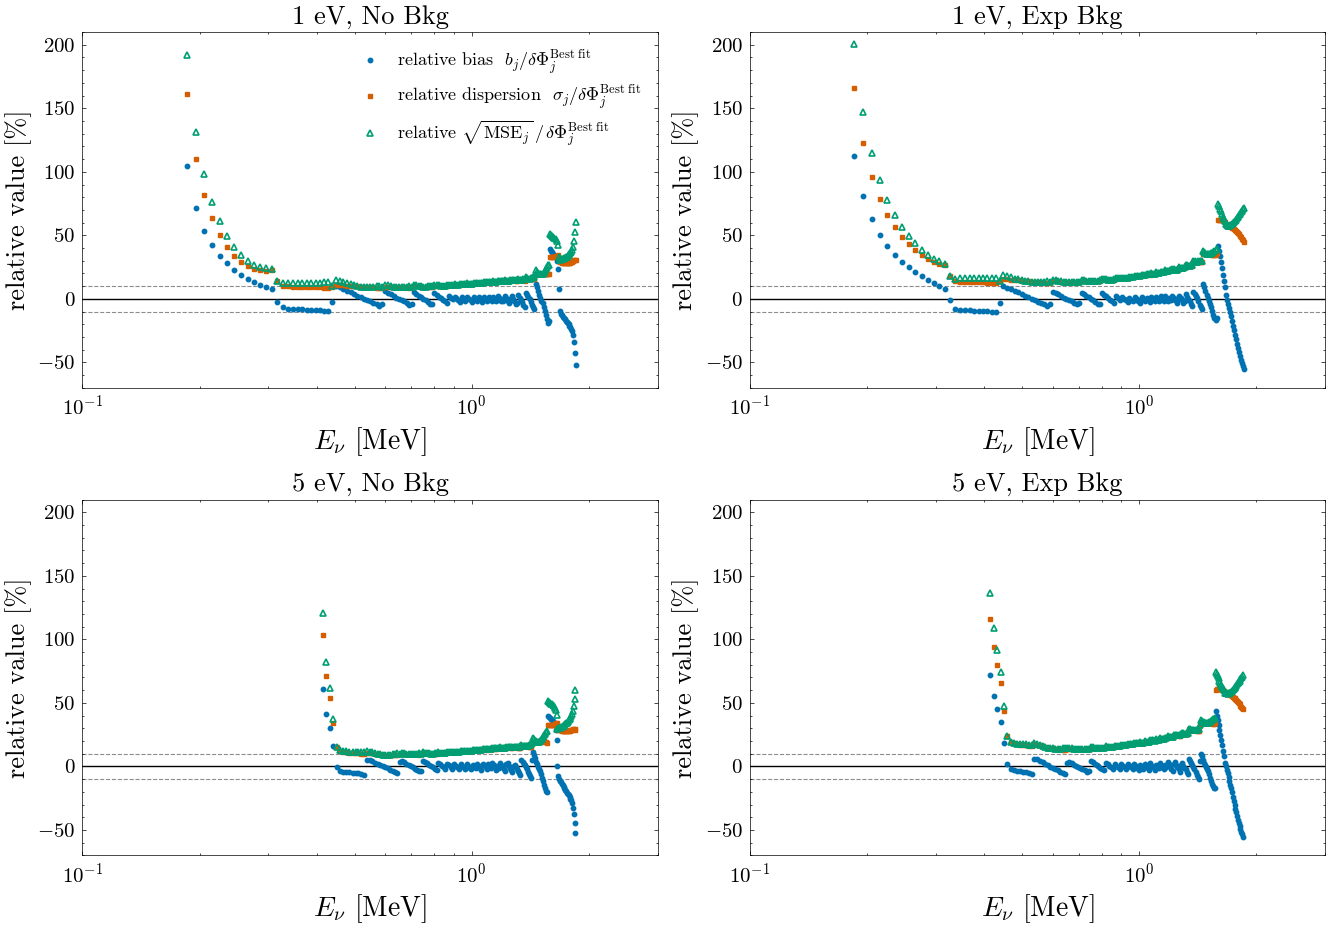

In [16]:
fig, axes = grid()
for ax, (thr, bkg, name) in zip(axes, CONFIGS):
    Ev, bf, b, sd, Meff = load(thr, bkg)
    ok = np.flatnonzero(bf > 0)
    if TRIM: ok = ok[:-TRIM]
    E = Ev[ok]
    ax.axhline(0, color='k', lw=1.0)
    ax.plot(E, 100*b[ok]/bf[ok], 'o', ms=3.2, color=CB,
            label=r'relative bias  ${b}_j/\delta\Phi_j^{\rm Best\ fit}$')
    ax.plot(E, 100*sd[ok]/bf[ok], 's', ms=3.2, color=CO,
            label=r'relative dispersion  $\sigma_j/\delta\Phi_j^{\rm Best\ fit}$')
    ax.plot(E, 100*np.sqrt(b[ok]**2+sd[ok]**2)/bf[ok], '^', ms=4.6, mfc='none', mec=CG, mew=1.2,
            label=r'relative $\sqrt{{\rm MSE}_j}\,/\,\delta\Phi_j^{\rm Best\ fit}$')
    if COMMON:
        for y in (10, -10): ax.axhline(y, color='0.55', lw=0.8, ls='--', zorder=1)
    ax.set_title(name, fontsize=19); axfmt(ax, 'relative value [%]')
    if COMMON: ax.set_ylim(-70, 210)
axes[0].legend(loc='upper right', fontsize=13, frameon=False)
finish(fig, 'relative_bias_disp_rmse')

## Fig. 13 — ${b}_j^2$, $\sigma_j^2$ and ${\rm MSE}_j$ in absolute units

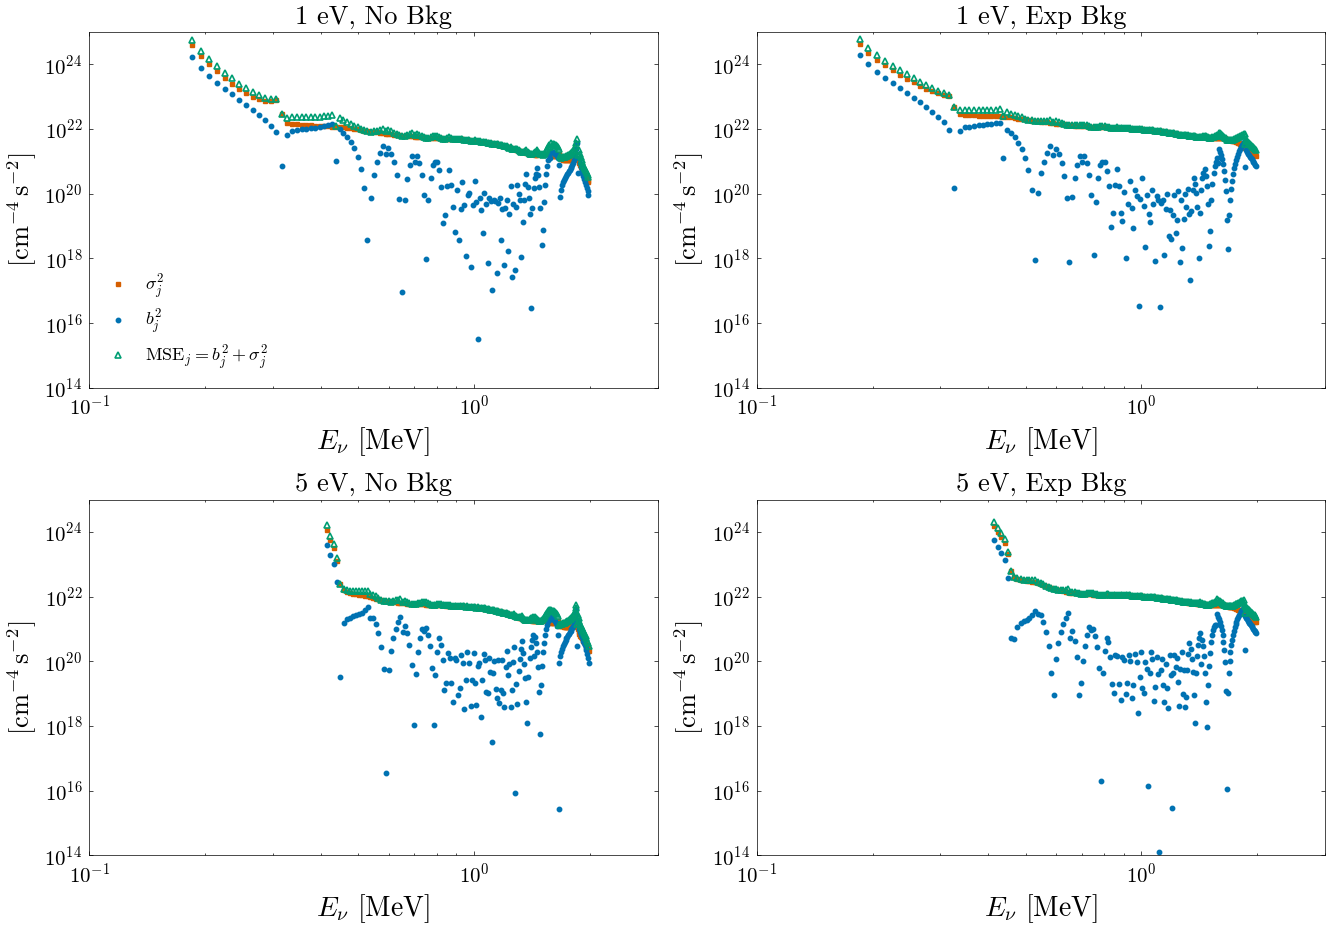

In [17]:
fig, axes = grid()
for ax, (thr, bkg, name) in zip(axes, CONFIGS):
    Ev, bf, b, sd, Meff = load(thr, bkg)
    if TRIM: Ev, b, sd = Ev[:-TRIM], b[:-TRIM], sd[:-TRIM]
    pos = b**2 > 0
    ax.plot(Ev, sd**2, 's', ms=3.2, color=CO, label=r'$\sigma_j^2$')
    ax.plot(Ev[pos], (b**2)[pos], 'o', ms=3.2, color=CB, label=r'${b}_j^2$')
    ax.plot(Ev, b**2+sd**2, '^', ms=4.6, mfc='none', mec=CG, mew=1.2,
            label=r'${\rm MSE}_j = {b}_j^2+\sigma_j^2$')
    ax.set_title(name, fontsize=19)
    axfmt(ax, r'$[{\rm cm^{-4}\,s^{-2}}]$', logy=True)
    if COMMON: ax.set_ylim(1e14, 1e25)
axes[0].legend(loc='lower left' if COMMON else 'upper right', fontsize=13, frameon=False)
finish(fig, 'abs_b2_s2_mse')

## Fig. 14 — ${b}_j^2/{\rm MSE}_j$
Black dashed: $0.5$ (${b}_j=\sigma_j$); gray dashed: $0.1$ and $1$.

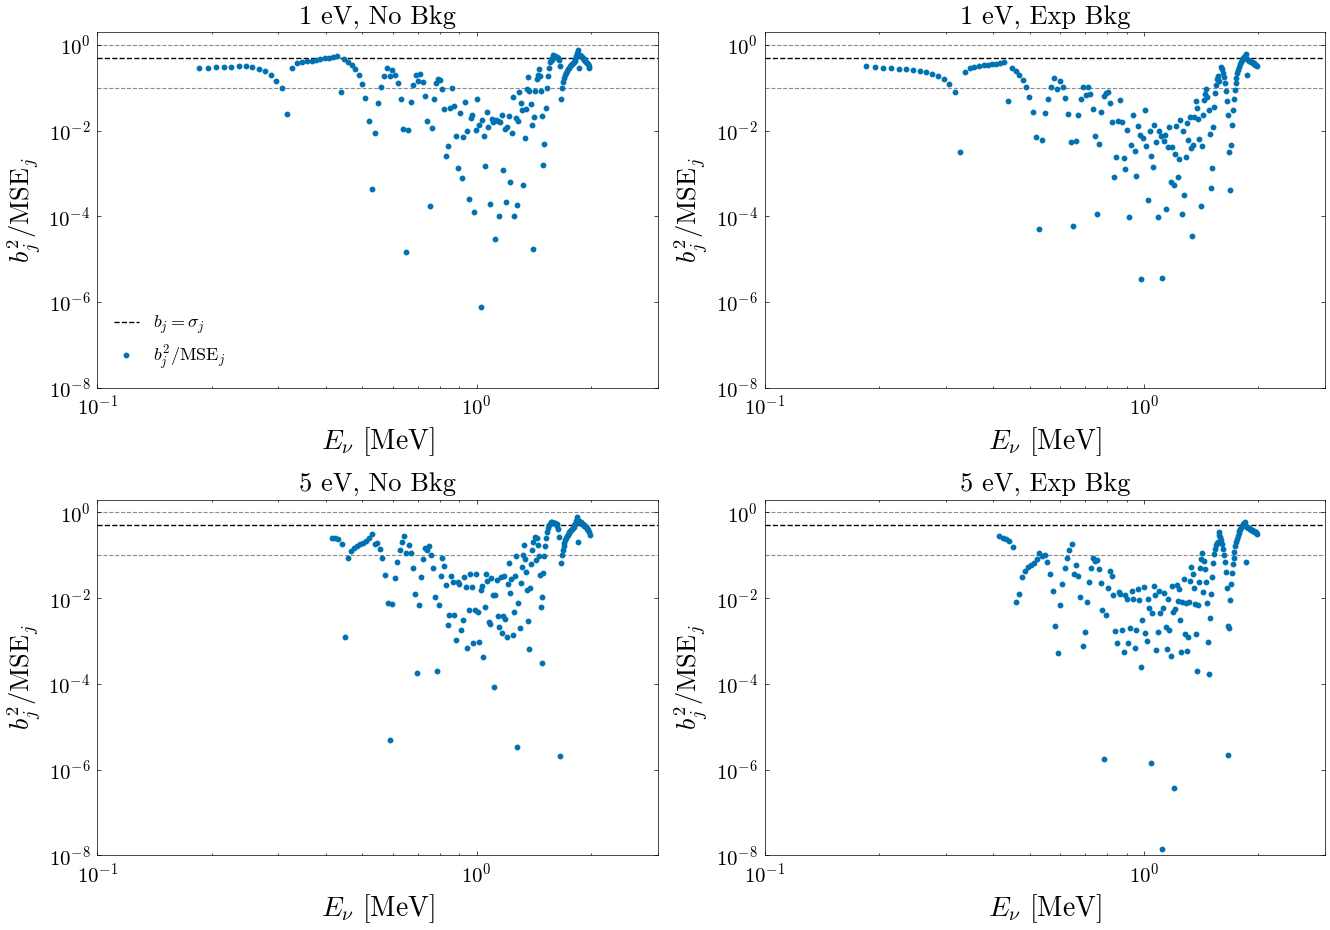

In [18]:
fig, axes = grid()
for ax, (thr, bkg, name) in zip(axes, CONFIGS):
    Ev, bf, b, sd, Meff = load(thr, bkg)
    if TRIM: Ev, b, sd = Ev[:-TRIM], b[:-TRIM], sd[:-TRIM]
    ax.axhline(0.5, color='k', lw=1.0, ls='--', label=r'${b}_j=\sigma_j$')
    if COMMON:
        for y in (0.1, 1.0): ax.axhline(y, color='0.55', lw=0.8, ls='--', zorder=1)
    ax.plot(Ev, b**2/(b**2+sd**2), 'o', ms=3.2, color=CB, label=r'${b}_j^2/{\rm MSE}_j$')
    ax.set_yscale('log'); ax.set_ylim((1e-8, 2) if COMMON else (None, 1.5))
    ax.set_title(name, fontsize=19)
    axfmt(ax, r'${b}_j^2/{\rm MSE}_j$', logy=True)
axes[0].legend(loc='lower left', fontsize=13, frameon=False)
finish(fig, 'ratio_b2_over_mse')

## Summary numbers

In [19]:
print(f"{'config':16s}{'med |relBias|':>14}{'med relDisp':>13}{'med relRMSE':>13}"
      f"{'med b2/MSE':>12}{'max b2/MSE':>12}")
for thr, bkg, name in CONFIGS:
    Ev, bf, b, sd, Meff = load(thr, bkg)
    ok = bf > 0
    rb, rs = np.abs(b[ok]/bf[ok]), sd[ok]/bf[ok]
    rmse = np.sqrt(b[ok]**2+sd[ok]**2)/bf[ok]
    q = b**2/(b**2+sd**2)
    print(f"{name:16s}{100*np.median(rb):13.2f}%{100*np.median(rs):12.1f}%"
      f"{100*np.median(rmse):12.1f}%{np.median(q):12.4f}{q.max():12.3f}")
# MC uncertainties:  Err(b_j) = sigma_j/sqrt(M) ,  Err(sigma_j^2) = sigma_j^2*sqrt(2/(M-1)) ~ 1.4%

config           med |relBias|  med relDisp  med relRMSE  med b2/MSE  max b2/MSE
1 eV, No Bkg             3.79%        13.8%        14.0%      0.1252       0.750
1 eV, Exp Bkg            3.69%        21.9%        21.9%      0.0499       0.602
5 eV, No Bkg             3.22%        14.3%        14.5%      0.0860       0.767
5 eV, Exp Bkg            2.93%        23.0%        23.1%      0.0241       0.606
